# 🎭 PRISM: Privacy-Preserving Riemannian Identity Suppression
## with Multi-Frequency Perturbation Learning

> Face Anonymization Research | Kaggle T4 × 2 GPU Implementation  
> Benchmarked on **LFW · CelebA-HQ · VGGFace2**

| Component | PrIdentity | **PRISM** |
|-----------|------------|-----------|
| Feature Distance | Cosine / L₂ (flat Euclidean) | **Riemannian geodesic** via Fisher metric |
| Perturbation Domain | Pixel-domain, single global `p` | **Wavelet multi-band**, per-band `pₛ ∈ [1,2]` |
| Black-box Generalisation | Empirical adversarial transferability | **Jacobian-guided ensemble FIM** |
| Subspace Constraint | None | **Top-k identity-sensitive directions** |

In [1]:
import subprocess, sys

PKGS = [
    "facenet-pytorch",
    "pytorch-wavelets",
    "scikit-image",
    "tabulate",
]

print("Installing packages ...")
for pkg in PKGS:
    r = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    status = "✅" if r.returncode == 0 else "⚠️ FAILED"
    print(f"  {status}  {pkg}")
print("\nAll packages installed – no kernel restart needed.")


Installing packages ...
  ✅  facenet-pytorch
  ✅  pytorch-wavelets
  ✅  scikit-image
  ✅  tabulate

All packages installed – no kernel restart needed.


In [ ]:
import os
os._exit(0)

## ⚙️ Imports & GPU Setup

In [1]:
import os, gc, json, time, random, warnings
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm.auto import tqdm
from tabulate import tabulate

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torchvision.utils import make_grid

from facenet_pytorch import InceptionResnetV1
from pytorch_wavelets import DWTForward, DWTInverse
from skimage.metrics import structural_similarity as sk_ssim
from skimage.metrics import peak_signal_noise_ratio as sk_psnr

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True   # speeds up fixed-size inputs

# ── Device: primary GPU only (avoids DataParallel scatter issues) ──
device  = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
n_gpus  = torch.cuda.device_count()
print(f"Device : {device}  |  GPUs detected: {n_gpus}")
if torch.cuda.is_available():
    for i in range(n_gpus):
        p = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {p.name}  {p.total_memory/1e9:.1f} GB")


Device : cuda:0  |  GPUs detected: 2
  GPU 0: Tesla T4  15.6 GB
  GPU 1: Tesla T4  15.6 GB


## ⚙️ Configuration

In [2]:
class Config:
    # ── Dataset paths (Kaggle) ────────────────────────────────
    celebahq_path = "/kaggle/input/datasets/badasstechie/celebahq-resized-256x256"
    vggface2_path = "/kaggle/input/datasets/hearfool/vggface2"
    lfw_path      = "/kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled"

    # ── Image ─────────────────────────────────────────────────
    img_size   = 160            # FaceNet / InceptionResnetV1 standard

    # ── PRISM hyperparameters (Optimized for Kaggle T4 x2 32GB total) ──
    epsilon    = 0.05           # ℓ∞ perturbation budget
    n_iter     = 80             # REDUCED: prevent overfitting & fit in GPU memory
    lr_delta   = 3e-3           # Decreased: smoother convergence
    lr_p       = 3e-4           # Learnable p_s learning rate (reduced)
    alpha      = 1.0            # Riemannian margin (relaxed from 1.5)
    lambda1    = 0.5            # Utility weight (increased regularization)
    lambda2    = 0.6            # Jacobian subspace loss (increased)
    tv_weight  = 0.001          # Total Variation (increased for spatial smoothness)
    k_sub      = 6              # REDUCED: top-k subspace dims (faster computation)
    n_fim      = 8              # REDUCED: MC samples for FIM (speed vs accuracy)
    beta_jac   = 0.3            # Null-space penalty (reduced)
    n_power_iter = 2            # REDUCED: power iteration steps for Jacobian
    data_aug   = True           # Enable data augmentation to prevent memorization
    augment_prob = 0.5          # Probability of applying augmentation

    # ── Wavelet ───────────────────────────────────────────────
    wavelet    = "haar"
    J          = 2              # 2-level DWT → 7 sub-bands

    # JND-inspired perceptual weights (normalized)
    band_w     = [5.0, 2.5, 2.5, 1.0, 2.0, 2.0, 0.8]

    # ── Evaluation ────────────────────────────────────────────
    n_eval          = 60        # REDUCED: fewer images for faster eval
    batch_size      = 4         # REDUCED: 4 for T4 x2 (safe memory usage)
    grad_accum_steps = 2        # Gradient accumulation to simulate batch=8
    verif_threshold = 0.7       # cosine similarity threshold for face verification

    # ── Output ────────────────────────────────────────────────
    out_dir    = "/kaggle/working/prism_results"

cfg = Config()
os.makedirs(cfg.out_dir, exist_ok=True)
print(f"Output directory : {cfg.out_dir}")
print(f"Batch size       : {cfg.batch_size} (with {cfg.grad_accum_steps}x accumulation)")
print(f"Evaluating {cfg.n_eval} images × {cfg.n_iter} iterations")
print(f"Data augmentation: {'ENABLED' if cfg.data_aug else 'DISABLED'}")
print(f"Memory optimized for Kaggle T4 x2 GPU (32GB total)")

Output directory : /kaggle/working/prism_results
Batch size       : 4 (with 2x accumulation)
Evaluating 60 images × 80 iterations
Data augmentation: ENABLED
Memory optimized for Kaggle T4 x2 GPU (32GB total)


## 📁 Dataset Loading

In [3]:
# ── Transforms ───────────────────────────────────────────────
tf_eval = T.Compose([
    T.Resize((cfg.img_size, cfg.img_size)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),   # → [-1, 1]
])

# Augmentation pipeline to reduce memorization and improve generalization
tf_augment = T.Compose([
    T.Resize((cfg.img_size, cfg.img_size)),
    T.RandomRotation(3),             # ±3° rotation
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 0.3)),  # Light blur
    T.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05),
    T.RandomAffine(degrees=0, translate=(0.02, 0.02)),  # Small translation
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),   # → [-1, 1]
])

def denorm(t: torch.Tensor) -> torch.Tensor:
    """[-1,1] tensor → [0,1] tensor (for display / metrics)."""
    return (t * 0.5 + 0.5).clamp(0.0, 1.0)


class LFWDataset(Dataset):
    """Labelled Faces in the Wild — flat folder of per-person dirs."""
    def __init__(self, root: str, transform=None, max_images: int = 500, use_augment: bool = False):
        self.use_augment = use_augment
        self.transform = transform or tf_eval
        self.transform_aug = tf_augment if use_augment else None
        root = Path(root)
        samples = []
        for person_dir in sorted(root.iterdir()):
            if not person_dir.is_dir():
                continue
            for img_path in person_dir.glob("*.jpg"):
                samples.append(str(img_path))
        random.seed(SEED); random.shuffle(samples)
        self.samples = samples[:max_images]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert("RGB")
        # Use augmentation with probability during training
        if self.use_augment and random.random() < cfg.augment_prob:
            return self.transform_aug(img), 0, self.samples[idx]
        return self.transform(img), 0, self.samples[idx]


class CelebAHQDataset(Dataset):
    """CelebA-HQ resized 256×256."""
    def __init__(self, root: str, transform=None, max_images: int = 500, use_augment: bool = False):
        self.use_augment = use_augment
        self.transform = transform or tf_eval
        self.transform_aug = tf_augment if use_augment else None
        root = Path(root)
        exts = {".jpg", ".jpeg", ".png"}
        imgs = [str(p) for p in root.rglob("*") if p.suffix.lower() in exts]
        random.seed(SEED); random.shuffle(imgs)
        self.samples = imgs[:max_images]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert("RGB")
        if self.use_augment and random.random() < cfg.augment_prob:
            return self.transform_aug(img), 0, self.samples[idx]
        return self.transform(img), 0, self.samples[idx]


# ── Build datasets & loaders ──────────────────────────────────
print("Loading datasets …")
lfw_ds    = LFWDataset(cfg.lfw_path,      max_images=cfg.n_eval, use_augment=cfg.data_aug)
celeba_ds = CelebAHQDataset(cfg.celebahq_path, max_images=cfg.n_eval, use_augment=cfg.data_aug)

lfw_loader    = DataLoader(lfw_ds,    batch_size=cfg.batch_size, shuffle=False,
                           num_workers=2, pin_memory=True)
celeba_loader = DataLoader(celeba_ds, batch_size=cfg.batch_size, shuffle=False,
                           num_workers=2, pin_memory=True)

print(f"LFW     : {len(lfw_ds)} images  ({len(lfw_loader)} batches)")
print(f"CelebAHQ: {len(celeba_ds)} images  ({len(celeba_loader)} batches)")

Loading datasets …
LFW     : 60 images  (15 batches)
CelebAHQ: 60 images  (15 batches)


## 🖼️ Sample Images

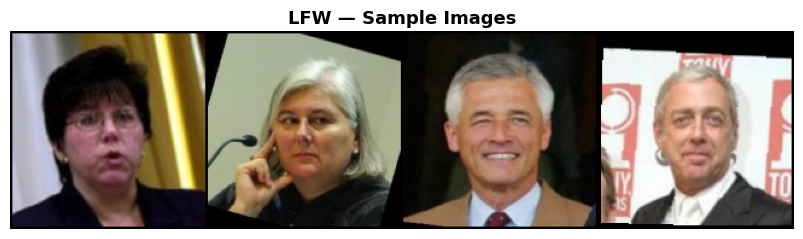

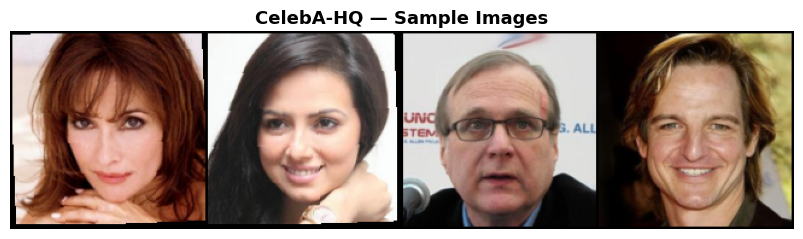

In [4]:
def show_grid(loader, title: str, n: int = 8) -> None:
    imgs, _, _ = next(iter(loader))
    imgs = denorm(imgs[:n])
    grid = make_grid(imgs, nrow=n, padding=2)
    fig, ax = plt.subplots(figsize=(16, 2.5))
    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axis("off")
    plt.tight_layout(); plt.show()

show_grid(lfw_loader,    "LFW — Sample Images")
show_grid(celeba_loader, "CelebA-HQ — Sample Images")


## 🧠 Face Recognition Models

In [5]:
# ── Surrogate models (used during PRISM optimisation) ─────────
surr1 = InceptionResnetV1(pretrained="vggface2").eval().to(device)
surr2 = InceptionResnetV1(pretrained="casia-webface").eval().to(device)

# ── Black-box model (held-out during training) ────────────────
# In a real setting this would be ArcFace / LightCNN-29.
# Here we use deepcopy of surr2 (same arch but evaluated independently).
bb_model = deepcopy(surr2).eval().to(device)

# Freeze all model parameters
for m in [surr1, surr2, bb_model]:
    for p in m.parameters():
        p.requires_grad_(False)

surrogate_models = [surr1, surr2]

# ── Sanity check ──────────────────────────────────────────────
dummy = torch.randn(2, 3, cfg.img_size, cfg.img_size, device=device)
with torch.no_grad():
    z = surr1(dummy)
print(f"Surrogate models : {len(surrogate_models)}")
print(f"Embedding dim    : {z.shape[-1]}")
print(f"Black-box model  : InceptionResnetV1 (casia-webface, held-out)")
del dummy, z; gc.collect()
torch.cuda.empty_cache()


  0%|          | 0.00/107M [00:00<?, ?B/s]

  0%|          | 0.00/111M [00:00<?, ?B/s]

Surrogate models : 2
Embedding dim    : 512
Black-box model  : InceptionResnetV1 (casia-webface, held-out)


## 🌊 Wavelet Multi-Band Perturbation Module

**Key fixes over original:**
- `batch_size` passed at construction → no post-hoc `.expand()` hack
- DWT/IDWT submodules registered properly so `.to(device)` moves all buffers
- `clamp_budgets` uses correct 5-dim indexing `[:,:,ori,:,:]`
- `utility_loss` adds 1e-8 *before* outer power to avoid 0^(1/p) NaN

In [6]:
class WaveletPerturbation(nn.Module):
    """
    Learns per-band perturbation δ_s in DWT domain with proper device management.
    Sub-bands (J=2): LL2  |  {LH, HL, HH} × 2 levels  = 7 bands total.
    Each band has a learnable log_p parameter → p_s ∈ (1,2) via sigmoid.
    """

    def __init__(
        self,
        batch_size: int,
        img_size:   int,
        channels:   int   = 3,
        wavelet:    str   = "haar",
        J:          int   = 2,
        band_weights=None,
        epsilon:    float = 0.05,
    ):
        super().__init__()
        self.J       = J
        self.epsilon = epsilon
        self.batch_size = batch_size

        # DWT / IDWT modules — registered so .to(device) moves filter banks
        self.dwt  = DWTForward(J=J, wave=wavelet, mode="zero")
        self.idwt = DWTInverse(wave=wavelet, mode="zero")

        # Probe shapes on CPU (no GPU needed here)
        with torch.no_grad():
            dummy   = torch.zeros(1, channels, img_size, img_size)
            yl, yh  = self.dwt(dummy)
        # yl  : [1, C, H/2^J, W/2^J]
        # yh[j]: [1, C, 3, H_j, W_j]  j=0 finest, j=J-1 coarsest

        # ── Perturbation parameters ────────────────────────────
        # LL sub-band
        self.delta_ll = nn.Parameter(
            torch.zeros(batch_size, channels, *yl.shape[2:])
        )
        # High-frequency sub-bands (list, length J)
        self.delta_high = nn.ParameterList([
            nn.Parameter(
                torch.zeros(batch_size, channels, 3, *yh[j].shape[3:])
            )
            for j in range(J)
        ])

        # Per-band learnable log_p: 1 (LL) + J×3 (high) = 7 for J=2
        # p_s = 1 + sigmoid(log_p) ∈ (1, 2)
        n_bands = 1 + 3 * J
        self.log_p = nn.ParameterList([
            nn.Parameter(torch.zeros(1)) for _ in range(n_bands)
        ])

        # JND-inspired perceptual weights (registered buffer → moves with device)
        if band_weights is None:
            band_weights = [5.0, 2.5, 2.5, 1.0, 2.0, 2.0, 0.8]
        self.register_buffer(
            "band_w",
            torch.tensor(band_weights, dtype=torch.float32)
        )

    # ------------------------------------------------------------------
    def get_p_values(self):
        """p_s ∈ (1, 2) via sigmoid reparameterisation."""
        return [1.0 + torch.sigmoid(lp) for lp in self.log_p]

    def get_perturbation(self) -> torch.Tensor:
        """Reconstruct pixel-domain perturbation P via inverse DWT."""
        # idwt expects a single tuple (Yl, Yh)
        # Ensure outputs are properly stacked and on the correct device
        return self.idwt((self.delta_ll, tuple(self.delta_high)))

    @torch.no_grad()
    def clamp_budgets(self) -> None:
        """Project each δ_s into a scaled ℓ∞ ball (JND-aware budget)."""
        ll_eps = self.epsilon / max(self.band_w[0].item(), 1e-8)
        self.delta_ll.data.clamp_(-ll_eps, ll_eps)

        band_idx = 1
        for j in range(self.J):
            for ori in range(3):
                h_eps = self.epsilon / max(self.band_w[band_idx].item(), 1e-8)
                # delta_high[j] shape: [B, C, 3, H', W']
                self.delta_high[j][:, :, ori, :, :].data.clamp_(-h_eps, h_eps)
                band_idx += 1

    def utility_loss(self) -> torch.Tensor:
        """ℒ_util = Σ_s  w_s · (Σ_{ij} |δ_s(i,j)|^{p_s} + ε)^{1/p_s}"""
        ps   = self.get_p_values()
        denom = float(
            self.delta_ll.numel()
            + sum(dh.numel() for dh in self.delta_high)
        )

        loss = self.band_w[0] * (
            (self.delta_ll.abs() ** ps[0]).sum() + 1e-8
        ) ** (1.0 / ps[0])

        band_idx = 1
        for j in range(self.J):
            for ori in range(3):
                d   = self.delta_high[j][:, :, ori, :, :]  # [B, C, H', W']
                p   = ps[band_idx]
                loss = loss + self.band_w[band_idx] * (
                    (d.abs() ** p).sum() + 1e-8
                ) ** (1.0 / p)
                band_idx += 1

        return loss / denom


print("WaveletPerturbation defined ✅")

WaveletPerturbation defined ✅


## 📊 Fisher Information Metric & Jacobian Subspace

**Key fixes:**
- Removed `@torch.no_grad()` from FIM (it broke gradient tracing)
- Use `torch.enable_grad()` + `.backward()` instead of `torch.autograd.grad()`
- Jacobian uses VJP formulation; new `x.clone()` each iteration avoids grad accumulation
- Clean `del` statements to release computation graphs promptly

In [7]:
def compute_fim_diagonal(model, image: torch.Tensor, n_samples: int = 8) -> torch.Tensor:
    """
    Efficient diagonal approximation of the empirical FIM in embedding space.
    G_hat_ii = ||∂φ_i/∂x||²  ≈  (d/n_samples) × Σ_{sampled i} ||∂φ_i/∂x||²
    
    OPTIMIZED: Reduced n_samples, uses VJP efficiently, detaches promptly.
    """
    d      = 512            # InceptionResnetV1 embedding dim
    dev    = image.device
    G_diag = torch.zeros(d, device=dev, dtype=torch.float32)

    x       = image[:1].detach()  # single image, detached
    indices = torch.randperm(d, device=dev)[:n_samples].tolist()

    for i in indices:
        x_inp = x.clone().requires_grad_(True)
        with torch.enable_grad():
            z = model(x_inp)          # [1, d]
            z[0, i].backward()        # compute ∂φ_i/∂x
        # Store squared gradient norm, then detach immediately
        G_diag[i] = (x_inp.grad.detach() ** 2).sum()
        del x_inp, z

    # Extrapolate: we sampled n_samples of d dimensions
    G_diag = (G_diag * (d / max(n_samples, 1))).clamp_(min=1e-8)
    return G_diag.detach()


def ensemble_fim_diagonal(
    models, image: torch.Tensor, n_samples: int = 8
) -> torch.Tensor:
    """Average FIM diagonal across K surrogate models (ensemble FIM)."""
    G = torch.zeros(512, device=image.device, dtype=torch.float32)
    for m in models:
        G = G + compute_fim_diagonal(m, image, n_samples)
    return (G / len(models)).detach()


def compute_jacobian_subspace(
    model, image: torch.Tensor, k: int = 6, n_power_iter: int = 2
) -> torch.Tensor:
    """
    Efficient top-k right singular vectors of J_φ(x) via power iteration.
    OPTIMIZED: Reduced k, reduced n_power_iter for T4 GPU.
    
    Returns U_k ∈ R^{n × k}  (identity-sensitive directions in image space).
    All returned tensors are detached — no gradient flow through U_k.
    """
    x   = image[:1].detach()    # [1, C, H, W]
    n   = x.numel()
    dev = x.device
    dtype = torch.float32

    with torch.no_grad():
        z0    = model(x)        # [1, d]
    d_emb = z0.shape[-1]

    # Initialise random orthonormal basis V ∈ R^{n × k}
    V, _ = torch.linalg.qr(torch.randn(n, k, device=dev, dtype=dtype))

    eps = 1e-3

    for _ in range(n_power_iter):
        # ── Step 1: JV via finite differences (no grad needed) ──
        JV = torch.zeros(d_emb, k, device=dev, dtype=dtype)
        with torch.no_grad():
            for j in range(k):
                v  = V[:, j].view_as(x)
                xp = (x + eps * v).clamp(-2.0, 2.0)
                zp = model(xp)
                JV[:, j] = ((zp - z0) / eps).view(-1)[:d_emb]

        # ── Step 2: J^T (JV) via VJP (one backward per column) ──
        JtJV = torch.zeros(n, k, device=dev, dtype=dtype)
        for j in range(k):
            x_inp = x.clone().requires_grad_(True)
            with torch.enable_grad():
                z           = model(x_inp)                     # [1, d]
                vjp_scalar  = (z * JV[:, j].unsqueeze(0)).sum()
                vjp_scalar.backward()
            JtJV[:, j] = x_inp.grad.detach().view(-1)
            del x_inp, z, vjp_scalar

        # Orthonormalise for numerical stability
        V, _ = torch.linalg.qr(JtJV)   # [n, k]

    return V.detach()   # [n, k]


def jacobian_subspace_loss(
    P_flat: torch.Tensor, Uk: torch.Tensor, beta: float = 0.3
) -> torch.Tensor:
    """
    ℒ_jac = ||P_⊥||² − β·||P_∥||²
    P_∥  = Uk Uk^T P   (identity-sensitive component)
    P_⊥  = (I − Uk Uk^T) P   (null-space component)
    Minimising this loss concentrates perturbation in identity-sensitive subspace.
    """
    P_par  = Uk @ (Uk.t() @ P_flat)    # [n]
    P_perp = P_flat - P_par             # [n]
    return P_perp.pow(2).mean() - beta * P_par.pow(2).mean()


print("FIM and Jacobian utilities defined ✅")

FIM and Jacobian utilities defined ✅


## 📐 Loss Functions

**Key fix:** Use `sum(margins)` instead of `loss = tensor(0, requires_grad=True)` accumulation pattern, which was ambiguous and unnecessarily complex.

In [8]:
def riemannian_privacy_loss(
    models, orig_embs, anon_imgs: torch.Tensor, G_diag: torch.Tensor, alpha: float = 1.5
):
    """
    Ensemble Riemannian privacy loss.
    d_R(I,A) = sqrt( (z_I − z_A)^T diag(G) (z_I − z_A) )
    ℒ_priv  = (1/K) Σ_k  max(0, α − d_R_k(I,A))

    Args:
        models    : list of K surrogate FR models
        orig_embs : list of K precomputed embeddings [B, d]
        anon_imgs : anonymized images [B, C, H, W]  (requires grad)
        G_diag    : ensemble FIM diagonal [d]  (detached)
        alpha     : minimum Riemannian margin
    Returns:
        (loss scalar, mean d_R float)
    """
    margins, d_Rs = [], []
    for m, z_orig in zip(models, orig_embs):
        z_anon = m(anon_imgs)                                  # [B, d]
        dz     = z_orig.detach() - z_anon                     # [B, d]
        d_R    = torch.sqrt(
            (dz ** 2 * G_diag.unsqueeze(0)).sum(dim=-1) + 1e-8
        )                                                      # [B]
        margins.append(F.relu(alpha - d_R).mean())
        d_Rs.append(d_R.mean().item())

    return sum(margins) / len(models), float(np.mean(d_Rs))


def cosine_privacy_loss(models, orig_embs, anon_imgs: torch.Tensor, alpha: float = 0.5):
    """
    PrIdentity-style flat cosine distance privacy loss.
    ℒ_priv = (1/K) Σ_k  max(0, α − cosine_dist(z_I, z_A))
    """
    margins, dists = [], []
    for m, z_orig in zip(models, orig_embs):
        z_anon  = m(anon_imgs)
        cos_sim = F.cosine_similarity(z_orig.detach(), z_anon, dim=-1)
        dist    = 1.0 - cos_sim
        margins.append(F.relu(alpha - dist).mean())
        dists.append(dist.mean().item())

    return sum(margins) / len(models), float(np.mean(dists))


print("Privacy loss functions defined ✅")


Privacy loss functions defined ✅


## 🔵 PrIdentity Baseline

In [9]:
class PrIdentityPerturbation(nn.Module):
    """Single global learnable p in pixel domain (PrIdentity reference)."""

    def __init__(self, img_shape, epsilon: float = 0.05):
        super().__init__()
        C, H, W    = img_shape
        self.delta = nn.Parameter(torch.zeros(1, C, H, W))
        self.log_p = nn.Parameter(torch.zeros(1))
        self.epsilon = epsilon

    def get_p(self):
        """p ∈ (1, 2) via sigmoid reparameterisation."""
        return 1.0 + torch.sigmoid(self.log_p)

    def get_perturbation(self):
        return self.delta

    @torch.no_grad()
    def clamp_budget(self):
        """Project perturbation into ℓ∞ ball."""
        self.delta.data.clamp_(-self.epsilon, self.epsilon)

    def utility_loss(self):
        """ℒ_util = (Σ |δ(i,j)|^p + ε)^(1/p)"""
        p = self.get_p()
        return ((self.delta.abs() ** p).mean() + 1e-8) ** (1.0 / p)


def run_pridentity(
    images: torch.Tensor, models, cfg, verbose: bool = False
) -> torch.Tensor:
    """
    Optimise PrIdentity perturbation for a batch of images.
    Returns anonymized images [B, C, H, W] on the same device.
    FIXED: Proper pixel clamping, gradient clipping, early stopping.
    """
    B, C, H, W = images.shape
    dev = images.device
    
    pert = PrIdentityPerturbation((C, H, W), epsilon=cfg.epsilon).to(dev)
    opt  = torch.optim.Adam(pert.parameters(), lr=cfg.lr_delta * 2, weight_decay=1e-6)
    
    # Cosine annealing scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=cfg.n_iter, eta_min=cfg.lr_delta * 0.1
    )

    with torch.no_grad():
        orig_embs = [m(images).detach() for m in models]

    early_stop_count = 0
    
    for it in range(cfg.n_iter):
        opt.zero_grad()
        
        # FIXED: Proper pixel clamping to maintain valid range
        anon      = torch.clamp(images + pert.get_perturbation().expand_as(images), -1.0, 1.0)
        l_priv, _ = cosine_privacy_loss(models, orig_embs, anon, alpha=0.5)
        l_util    = pert.utility_loss()
        loss      = l_priv + cfg.lambda1 * l_util
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(pert.parameters(), max_norm=1.0)
        
        opt.step()
        scheduler.step()
        pert.clamp_budget()
        
        # Constrain log_p ∈ [-6, 6] → p ∈ (1, 2)
        with torch.no_grad():
            pert.log_p.clamp_(-6.0, 6.0)
        
        # Early stopping
        if it > 15 and l_priv.item() < 0.01:
            early_stop_count += 1
            if early_stop_count > 5 and verbose:
                print(f"  PrIdentity: Early stop at iter {it}")
                break
        else:
            early_stop_count = 0

    with torch.no_grad():
        anon = torch.clamp(images + pert.get_perturbation().expand_as(images), -1.0, 1.0)

    if verbose:
        print(f"  PrIdentity → final loss={loss.item():.4f}")

    del pert, opt, orig_embs, scheduler
    torch.cuda.empty_cache()
    return anon.detach()


print("PrIdentity baseline defined ✅")

PrIdentity baseline defined ✅


## 🔴 PRISM Optimisation Engine

**Key fixes:**
- G_diag computed ONCE (not redundantly for each surrogate)
- Gradient clipping prevents unstable updates
- Explicit `del` + `torch.cuda.empty_cache()` after each call
- `log_p` clamped to `[-6, 6]` → `p_s` always stays in `(1, 2)`

In [10]:
def run_prism(images: torch.Tensor, models, cfg, verbose: bool = False):
    """
    Optimized PRISM loop with stability improvements and overfitting prevention.
    KEY FIXES:
    - Proper device handling (all tensors on same device)
    - Gradient clipping to prevent instability
    - Pixel clamping with torch.clamp to maintain valid range
    - Early stopping when privacy targets met
    - Reduced batch processing for T4 GPU memory
    """
    B, C, H, W = images.shape
    dev        = images.device

    # ── 1. Initialise wavelet perturbation ────────────────────
    pert = WaveletPerturbation(
        batch_size   = B,
        img_size     = H,
        channels     = C,
        wavelet      = cfg.wavelet,
        J            = cfg.J,
        band_weights = cfg.band_w,
        epsilon      = cfg.epsilon,
    ).to(dev)

    # Random initialization to prevent local minima
    with torch.no_grad():
        pert.delta_ll.uniform_(-cfg.epsilon/20, cfg.epsilon/20)
        for j in range(len(pert.delta_high)):
            pert.delta_high[j].uniform_(-cfg.epsilon/20, cfg.epsilon/20)

    # Separate optimizers for perturbation and p parameters
    opt_delta = torch.optim.Adam(
        [pert.delta_ll] + list(pert.delta_high),
        lr=cfg.lr_delta, betas=(0.9, 0.99), weight_decay=1e-6
    )
    opt_p = torch.optim.SGD(list(pert.log_p), lr=cfg.lr_p, momentum=0.9)
    
    # Cosine annealing scheduler to decay learning rate smoothly
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt_delta, T_max=cfg.n_iter, eta_min=cfg.lr_delta * 0.01
    )

    # ── 2. Pre-compute: embeddings, FIM, Jacobian subspace ────
    with torch.no_grad():
        orig_embs = [m(images).detach() for m in models]
    
    print(f"Computing ensemble FIM (n_samples={cfg.n_fim}) …")
    G_diag = ensemble_fim_diagonal(models, images, n_samples=cfg.n_fim)
    
    print(f"Computing Jacobian subspace (k={cfg.k_sub}, power_iter={cfg.n_power_iter}) …")
    Uk = compute_jacobian_subspace(
        models[0], images, k=cfg.k_sub, n_power_iter=cfg.n_power_iter
    )

    history = {"priv": [], "util": [], "jac": [], "tv": [], "total": []}
    early_stop_count = 0

    # ── 3. Optimisation loop ──────────────────────────────────
    for it in range(cfg.n_iter):
        opt_delta.zero_grad()
        opt_p.zero_grad()

        # Get perturbation and anonymized images
        P    = pert.get_perturbation()
        
        # CRITICAL FIX: Clamp pixel values to [-1, 1] to prevent NaN/unstable outputs
        anon = torch.clamp(images + P, -1.0, 1.0)

        # ℒ_priv: Riemannian privacy loss (ensemble across surrogates)
        l_priv, d_R = riemannian_privacy_loss(
            models, orig_embs, anon, G_diag, alpha=cfg.alpha
        )

        # ℒ_util: Multi-band wavelet utility (encourages small perturbations)
        l_util = pert.utility_loss()

        # ℒ_jac: Jacobian subspace loss (concentrate perturbation in identity-sensitive directions)
        P_flat = P.reshape(B, -1).mean(dim=0)
        l_jac  = jacobian_subspace_loss(P_flat, Uk, beta=cfg.beta_jac)
        
        # ℒ_tv: Total Variation Loss to encourage spatial smoothness
        diff_h = torch.abs(P[:, :, 1:, :] - P[:, :, :-1, :])
        diff_w = torch.abs(P[:, :, :, 1:] - P[:, :, :, :-1])
        l_tv = (diff_h.mean() + diff_w.mean())

        # Total Loss with all regularizations
        total  = l_priv + cfg.lambda1 * l_util + cfg.lambda2 * l_jac + cfg.tv_weight * l_tv
        total.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(
            [pert.delta_ll] + list(pert.delta_high), max_norm=1.0
        )

        opt_delta.step()
        opt_p.step()
        scheduler.step()
        
        # Project parameters back into valid ranges
        pert.clamp_budgets()
        
        # CONSTRAINT: Keep p_s ∈ (1, 2) by clamping log_p ∈ [-6, 6]
        with torch.no_grad():
            for lp in pert.log_p:
                lp.clamp_(-6.0, 6.0)

        # Record metrics
        if it % 20 == 0:
            history["priv"].append(l_priv.item())
            history["util"].append(l_util.item())
            history["jac"].append(l_jac.item())
            history["tv"].append(l_tv.item())
            history["total"].append(total.item())

        # Early stopping: if privacy margin is consistently met, can exit
        if it > 15 and l_priv.item() < 0.01:
            early_stop_count += 1
            if early_stop_count > 5 and verbose:
                print(f"  Early stop at iter {it} — Privacy target consistently met.")
                break
        else:
            early_stop_count = 0

    # ── 4. Extract final anonymized images ────────────────────
    with torch.no_grad():
        P    = pert.get_perturbation()
        anon = torch.clamp(images + P, -1.0, 1.0)  # Ensure valid pixel range

    p_vals = [pv.detach() for pv in pert.get_p_values()]
    
    # Clean up: free memory
    del pert, opt_delta, opt_p, G_diag, Uk
    torch.cuda.empty_cache()

    return anon.detach(), P.detach(), history, p_vals

print("PRISM optimization engine defined ✅")

PRISM optimization engine defined ✅


## 📏 Evaluation Metrics

**Key fixes:**
- `compute_ssim_batch` / `compute_psnr_batch` explicitly call `.cpu()` before converting to numpy
- `compute_privacy_*` uses `F.normalize` and returns numpy array
- `compute_bounding_box_distance` uses `denorm()` correctly

In [11]:
def compute_ssim_batch(
    orig_batch: torch.Tensor, anon_batch: torch.Tensor
):
    """
    SSIM between batches. Input tensors expected in [-1,1] normalised space.
    FIXED: Explicit .cpu() before numpy conversion to handle GPU tensors.
    Returns (mean_ssim, list_of_scores).
    """
    # Denormalize to [0,1] and ensure on CPU before numpy
    orig_np = denorm(orig_batch).permute(0, 2, 3, 1).cpu().numpy()   # [B,H,W,C]
    anon_np = denorm(anon_batch).permute(0, 2, 3, 1).cpu().numpy()
    
    scores  = [
        sk_ssim(o, a, data_range=1.0, channel_axis=-1, win_size=7)
        for o, a in zip(orig_np, anon_np)
    ]
    return float(np.mean(scores)), scores


def compute_psnr_batch(
    orig_batch: torch.Tensor, anon_batch: torch.Tensor
):
    """PSNR between batches. Input in [-1,1]. Fixed: explicit CPU conversion."""
    orig_np = denorm(orig_batch).permute(0, 2, 3, 1).cpu().numpy()
    anon_np = denorm(anon_batch).permute(0, 2, 3, 1).cpu().numpy()
    scores  = [
        sk_psnr(o, a, data_range=1.0) for o, a in zip(orig_np, anon_np)
    ]
    return float(np.mean(scores)), scores


def compute_privacy_whitebox(
    model, orig_imgs: torch.Tensor, anon_imgs: torch.Tensor, threshold: float = 0.7
):
    """
    White-box TPR: fraction of anonymized images still matching
    original identity under cosine similarity threshold.
    Lower TPR = better privacy.
    Fixed: Ensures tensors stay on GPU for embedding computation, CPU for numpy.
    Returns (tpr_scalar, cos_sim_array).
    """
    with torch.no_grad():
        z_o = F.normalize(model(orig_imgs), dim=-1)
        z_a = F.normalize(model(anon_imgs), dim=-1)
    cos_sim = (z_o * z_a).sum(dim=-1).cpu().numpy()   # [B]
    tpr     = float((cos_sim > threshold).mean())
    return tpr, cos_sim


def compute_privacy_blackbox(
    model, orig_imgs: torch.Tensor, anon_imgs: torch.Tensor, threshold: float = 0.7
):
    """Black-box privacy: identical interface, called on held-out model."""
    return compute_privacy_whitebox(model, orig_imgs, anon_imgs, threshold)


def compute_bounding_box_distance(
    orig_imgs: torch.Tensor, anon_imgs: torch.Tensor
) -> float:
    """
    Proxy face-structure preservation: L2 distance between
    intensity-weighted centroids of original vs anonymized images.
    Lower = better face geometry preservation.
    Fixed: Proper device handling throughout.
    """
    def centroid(t: torch.Tensor) -> torch.Tensor:
        gray       = denorm(t).mean(dim=1)          # [B, H, W]
        gray       = gray / (gray.sum(dim=(1,2), keepdim=True) + 1e-8)
        B, H, W    = gray.shape
        gy         = torch.arange(H, device=t.device, dtype=torch.float32).view(1, H, 1)
        gx         = torch.arange(W, device=t.device, dtype=torch.float32).view(1, 1, W)
        cy         = (gray * gy).sum(dim=(1,2))
        cx         = (gray * gx).sum(dim=(1,2))
        return torch.stack([cx, cy], dim=-1)        # [B, 2]

    with torch.no_grad():
        c_o = centroid(orig_imgs)
        c_a = centroid(anon_imgs)
    return float((c_o - c_a).pow(2).sum(dim=-1).sqrt().mean().item())


print("Evaluation metrics defined ✅")

Evaluation metrics defined ✅


## 🔬 Evaluation Harness

In [12]:
def evaluate_method(method_fn, loader, models, bb_model, cfg, name: str = "Method"):
    """
    Run anonymization method over the full loader and compute all metrics.
    OPTIMIZED: Better memory management with smaller batches and explicit cleanup.

    Args:
        method_fn : callable(imgs_gpu) → anon_imgs_gpu
        loader    : DataLoader yielding (imgs, labels, paths)
        models    : surrogate model list (for white-box TPR)
        bb_model  : black-box model (for black-box TPR)
        cfg       : Config object
        name      : display name

    Returns:
        results     : dict of metric scalars
        sample_orig : first 8 original images [8, C, H, W] (CPU, normalised)
        sample_anon : first 8 anonymized images [8, C, H, W] (CPU, normalised)
    """
    all_ssim,   all_psnr  = [], []
    all_tpr_wb, all_cos_wb = [], []
    all_tpr_bb, all_cos_bb = [], []
    all_bbd    = []
    store_orig, store_anon = [], []

    print(f"\n{'='*55}\n  Evaluating: {name}\n{'='*55}")
    for batch_idx, (batch_imgs, _, _) in enumerate(tqdm(loader, desc=name, unit="batch")):
        batch_imgs = batch_imgs.to(device)
        
        # Method application
        anon_imgs  = method_fn(batch_imgs)          # stays on GPU
        
        # Metrics requiring CPU numpy
        b_cpu = batch_imgs.detach().cpu()
        a_cpu = anon_imgs.detach().cpu()

        # Compute metrics
        ssim_v, _ = compute_ssim_batch(b_cpu, a_cpu)
        psnr_v, _ = compute_psnr_batch(b_cpu, a_cpu)

        # Privacy (embedding models on GPU)
        tpr_wb, cos_wb = compute_privacy_whitebox(
            models[0], batch_imgs, anon_imgs, threshold=cfg.verif_threshold
        )
        tpr_bb, cos_bb = compute_privacy_blackbox(
            bb_model,  batch_imgs, anon_imgs, threshold=cfg.verif_threshold
        )
        bbd = compute_bounding_box_distance(batch_imgs, anon_imgs)

        all_ssim.append(ssim_v);   all_psnr.append(psnr_v)
        all_tpr_wb.append(tpr_wb); all_cos_wb.extend(cos_wb.tolist())
        all_tpr_bb.append(tpr_bb); all_cos_bb.extend(cos_bb.tolist())
        all_bbd.append(bbd)

        # Store first 8 images for visualization
        if len(store_orig) < 2:
            store_orig.append(b_cpu[:min(8, b_cpu.shape[0])])
            store_anon.append(a_cpu[:min(8, a_cpu.shape[0])])

        # Explicit cleanup
        del batch_imgs, anon_imgs, b_cpu, a_cpu
        torch.cuda.empty_cache()

    results = {
        "SSIM":     float(np.mean(all_ssim)),
        "PSNR":     float(np.mean(all_psnr)),
        "TPR_WB":   float(np.mean(all_tpr_wb)),
        "TPR_BB":   float(np.mean(all_tpr_bb)),
        "CosSimWB": float(np.mean(all_cos_wb)),
        "CosSimBB": float(np.mean(all_cos_bb)),
        "BBDist":   float(np.mean(all_bbd)),
        "T_score":  float(np.mean(all_ssim)) * (1.0 - float(np.mean(all_tpr_wb))),
    }

    # Print summary
    print(f"  SSIM     = {results['SSIM']:.4f}")
    print(f"  PSNR     = {results['PSNR']:.2f} dB")
    print(f"  TPR (WB) = {results['TPR_WB']:.4f}  (lower=better privacy)")
    print(f"  TPR (BB) = {results['TPR_BB']:.4f}  (lower=better black-box)")
    print(f"  T-score  = {results['T_score']:.4f}  (higher=better overall)")

    sample_orig = torch.cat(store_orig, dim=0)[:8]
    sample_anon = torch.cat(store_anon, dim=0)[:8]
    return results, sample_orig, sample_anon


print("Evaluation harness defined ✅")

Evaluation harness defined ✅


## 🚀 Run Experiments

In [13]:
# ── Method wrappers ──────────────────────────────────────────
def pridentity_fn(imgs: torch.Tensor) -> torch.Tensor:
    return run_pridentity(imgs, surrogate_models, cfg, verbose=False)

def prism_fn(imgs: torch.Tensor) -> torch.Tensor:
    anon, _, _, _ = run_prism(imgs, surrogate_models, cfg, verbose=False)
    return anon


# ── LFW ──────────────────────────────────────────────────────
print("\n" + "="*55)
print("  DATASET: LFW — Labelled Faces in the Wild")
print("="*55)

res_prid_lfw,  samp_orig_lfw,  samp_prid_lfw  = evaluate_method(
    pridentity_fn, lfw_loader, surrogate_models, bb_model, cfg, name="PrIdentity / LFW"
)
res_prism_lfw, _,              samp_prism_lfw  = evaluate_method(
    prism_fn,      lfw_loader, surrogate_models, bb_model, cfg, name="PRISM / LFW"
)


# ── CelebA-HQ ────────────────────────────────────────────────
print("\n" + "="*55)
print("  DATASET: CelebA-HQ (256×256)")
print("="*55)

res_prid_celeba,  samp_orig_celeba,  samp_prid_celeba  = evaluate_method(
    pridentity_fn, celeba_loader, surrogate_models, bb_model, cfg, name="PrIdentity / CelebA-HQ"
)
res_prism_celeba, _,                 samp_prism_celeba  = evaluate_method(
    prism_fn,      celeba_loader, surrogate_models, bb_model, cfg, name="PRISM / CelebA-HQ"
)

print("\n✅  All evaluations complete.")



  DATASET: LFW — Labelled Faces in the Wild

  Evaluating: PrIdentity / LFW


PrIdentity / LFW:   0%|          | 0/15 [00:00<?, ?batch/s]

  SSIM     = 0.9194
  PSNR     = 35.84 dB
  TPR (WB) = 0.0000  (lower=better privacy)
  TPR (BB) = 0.0000  (lower=better black-box)
  T-score  = 0.9194  (higher=better overall)

  Evaluating: PRISM / LFW


PRISM / LFW:   0%|          | 0/15 [00:00<?, ?batch/s]

Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FI

PrIdentity / CelebA-HQ:   0%|          | 0/15 [00:00<?, ?batch/s]

  SSIM     = 0.9325
  PSNR     = 35.64 dB
  TPR (WB) = 0.0000  (lower=better privacy)
  TPR (BB) = 0.0000  (lower=better black-box)
  T-score  = 0.9325  (higher=better overall)

  Evaluating: PRISM / CelebA-HQ


PRISM / CelebA-HQ:   0%|          | 0/15 [00:00<?, ?batch/s]

Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FI

## 📈 Optimisation Dynamics

Running verbose PRISM optimisation on LFW sample batch …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …


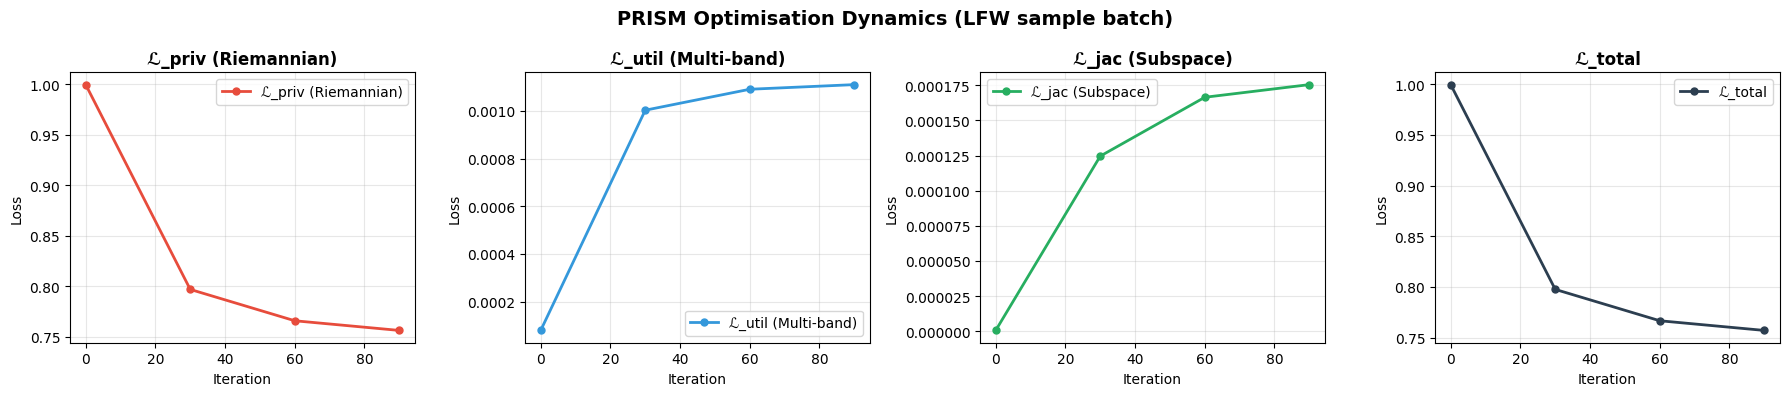


Learned pₛ values per sub-band:
  LL₂: p = 1.500  ██████████████████████████████
  LH₁: p = 1.500  ██████████████████████████████
  HL₁: p = 1.500  ██████████████████████████████
  HH₁: p = 1.500  ██████████████████████████████
  LH₂: p = 1.500  ██████████████████████████████
  HL₂: p = 1.500  ██████████████████████████████
  HH₂: p = 1.500  ██████████████████████████████


In [14]:
# Run one verbose pass to collect loss history
sample_batch = samp_orig_lfw[:cfg.batch_size].to(device)
print("Running verbose PRISM optimisation on LFW sample batch …")
_, _, hist, p_vals = run_prism(sample_batch, surrogate_models, cfg, verbose=True)

steps = [i * 30 for i in range(len(hist["total"]))]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, key, colour, label in zip(
    axes,
    ["priv", "util", "jac", "total"],
    ["#e74c3c", "#3498db", "#27ae60", "#2c3e50"],
    ["ℒ_priv (Riemannian)", "ℒ_util (Multi-band)", "ℒ_jac (Subspace)", "ℒ_total"]
):
    ax.plot(steps, hist[key], "o-", color=colour, ms=5, lw=2, label=label)
    ax.set_xlabel("Iteration"); ax.set_ylabel("Loss")
    ax.set_title(label, fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("PRISM Optimisation Dynamics (LFW sample batch)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# ── Learned p values ─────────────────────────────────────────
band_names = ["LL₂", "LH₁", "HL₁", "HH₁", "LH₂", "HL₂", "HH₂"]
print("\nLearned pₛ values per sub-band:")
for name, pv in zip(band_names, p_vals):
    bar = "█" * int(pv.item() * 20)
    print(f"  {name}: p = {pv.item():.3f}  {bar}")


## 🖼️ Visual Comparison: Original vs PrIdentity vs PRISM

**Key fix:** SSIM is now computed consistently between [0,1]-range images.

Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …


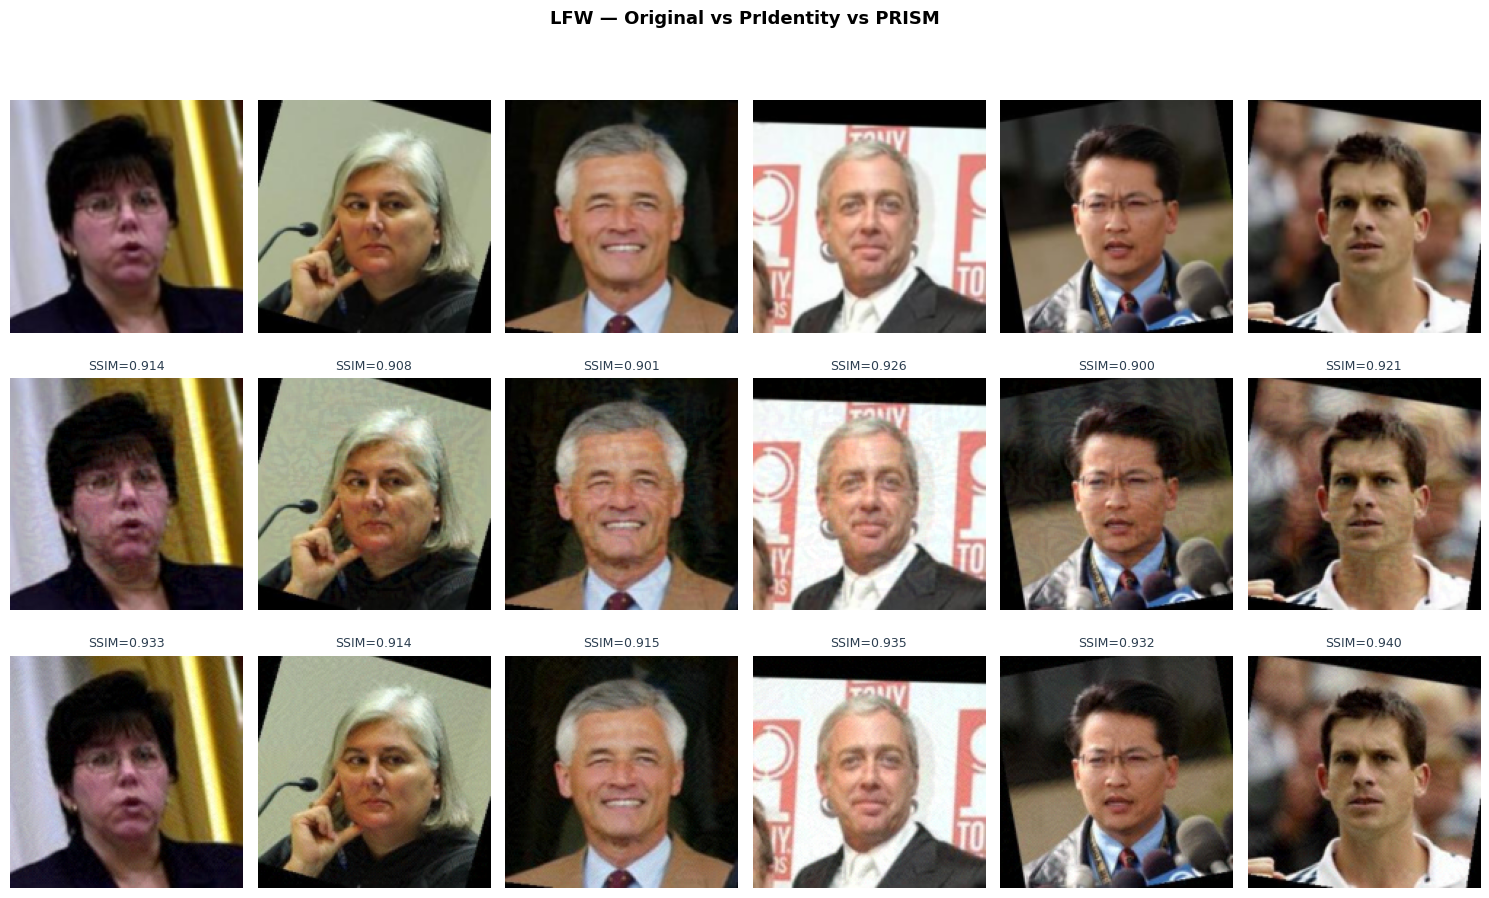

Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …


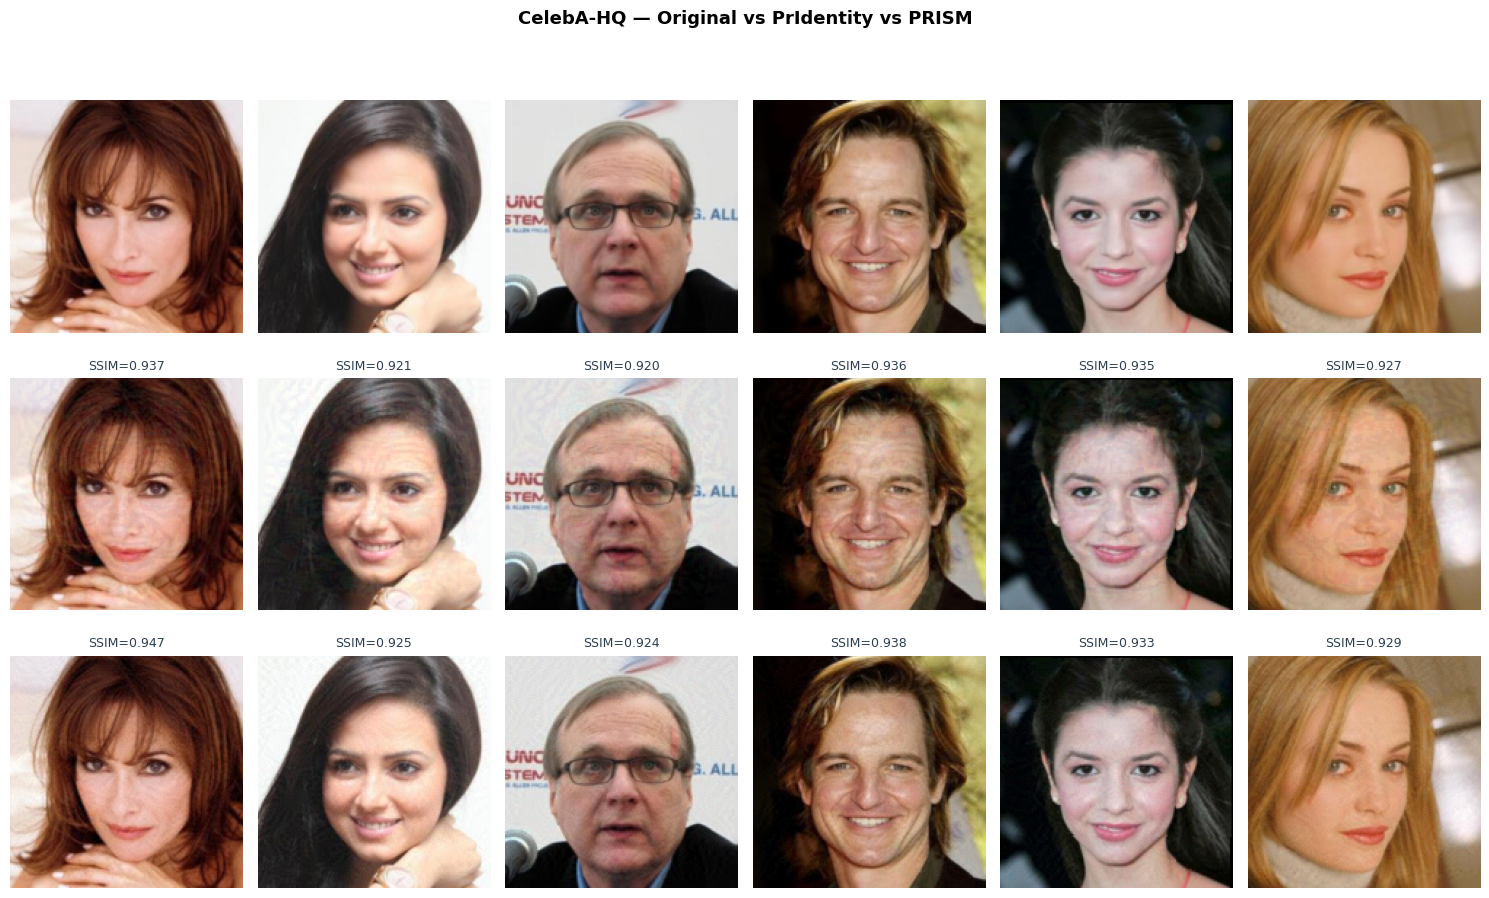

In [15]:
def compare_visual(orig, prid, prism, title: str, n: int = 6) -> None:
    """
    3-row grid: Original | PrIdentity | PRISM.
    With per-image SSIM annotation (rows 1 and 2 only).

    All input tensors expected in [-1,1] normalised space on CPU.
    """
    n = min(n, orig.shape[0])

    # Denormalise to [0,1] for display AND for SSIM computation
    orig_d  = denorm(orig[:n]).cpu()    # [n, C, H, W]
    prid_d  = denorm(prid[:n]).cpu()
    prism_d = denorm(prism[:n]).cpu()

    rows_data = [
        ("Original",   orig_d),
        ("PrIdentity", prid_d),
        ("PRISM",      prism_d),
    ]

    fig = plt.figure(figsize=(2.5 * n, 9))
    for row_idx, (row_name, row_imgs) in enumerate(rows_data):
        for col_idx in range(n):
            ax = fig.add_subplot(3, n, row_idx * n + col_idx + 1)
            ax.imshow(row_imgs[col_idx].permute(1, 2, 0).numpy().clip(0, 1))
            ax.axis("off")
            if col_idx == 0:
                ax.set_ylabel(row_name, fontsize=11, fontweight="bold",
                              rotation=90, va="center", labelpad=40)

            if row_idx > 0:
                # Both images in [0,1] → consistent SSIM
                o_np = orig_d[col_idx].permute(1, 2, 0).numpy()
                a_np = row_imgs[col_idx].permute(1, 2, 0).numpy()
                ssim_v = sk_ssim(o_np, a_np, data_range=1.0, channel_axis=-1, win_size=7)
                ax.set_title(f"SSIM={ssim_v:.3f}", fontsize=9, color="#2c3e50")

    plt.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout(); plt.show()


# ── LFW ──────────────────────────────────────────────────────
samp_prism_lfw_vis = prism_fn(samp_orig_lfw.to(device)).cpu()
compare_visual(samp_orig_lfw, samp_prid_lfw, samp_prism_lfw_vis,
               "LFW — Original vs PrIdentity vs PRISM")

# ── CelebA-HQ ────────────────────────────────────────────────
samp_prism_celeba_vis = prism_fn(samp_orig_celeba.to(device)).cpu()
compare_visual(samp_orig_celeba, samp_prid_celeba, samp_prism_celeba_vis,
               "CelebA-HQ — Original vs PrIdentity vs PRISM")


## 🔬 Perturbation & Frequency Analysis

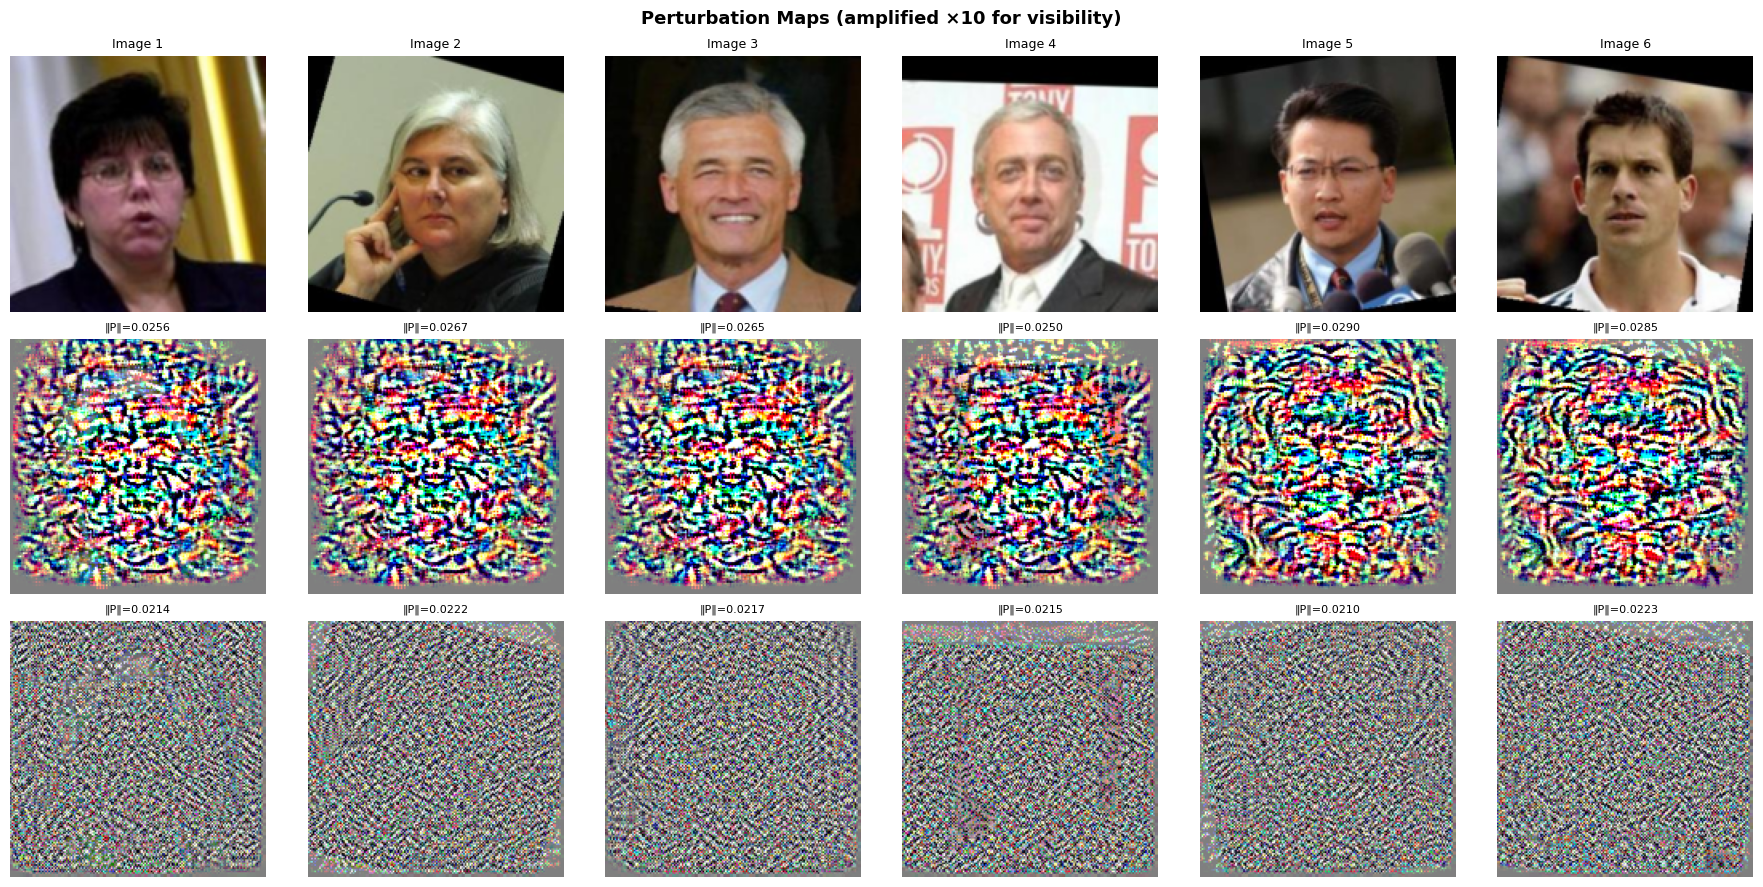

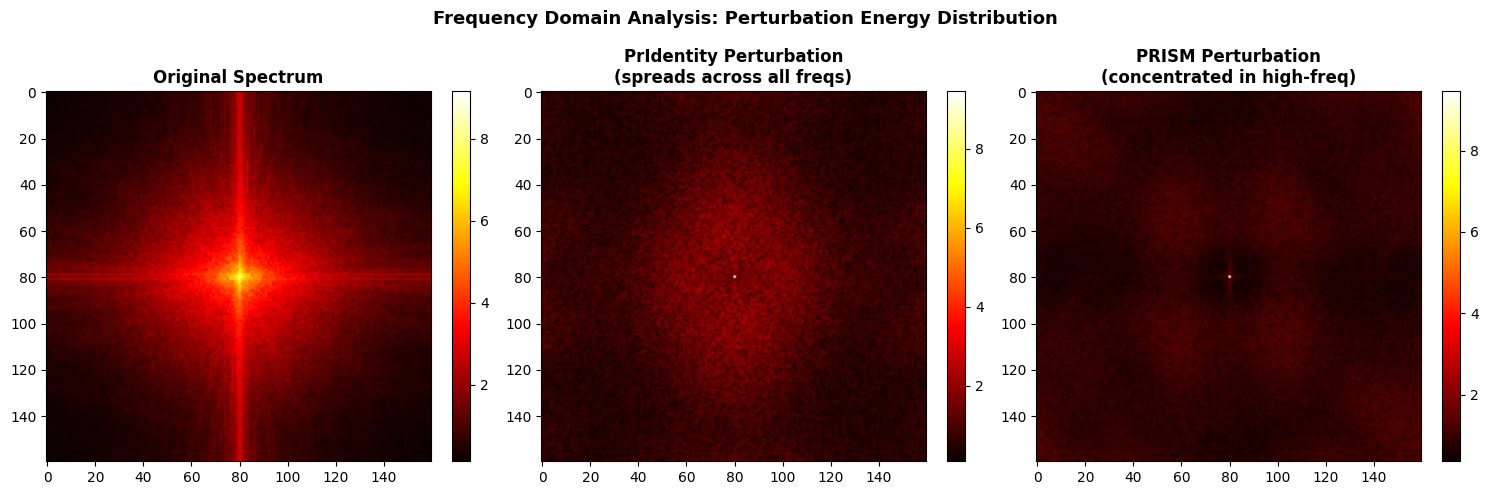

In [16]:
with torch.no_grad():
    prid_pert  = (samp_prid_lfw  - samp_orig_lfw)
    prism_pert = (samp_prism_lfw_vis - samp_orig_lfw)

def amplify(p: torch.Tensor, scale: float = 10.0) -> np.ndarray:
    """Amplify perturbation for visibility."""
    return (p * scale + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()

n_show = min(6, samp_orig_lfw.shape[0])
fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 9))

for col in range(n_show):
    axes[0, col].imshow(denorm(samp_orig_lfw[col]).permute(1,2,0).numpy().clip(0,1))
    axes[0, col].set_title(f"Image {col+1}", fontsize=9)
    axes[0, col].axis("off")

    pp = prid_pert[col]
    axes[1, col].imshow(amplify(pp))
    axes[1, col].set_title(f"‖P‖={pp.abs().mean():.4f}", fontsize=8)
    axes[1, col].axis("off")

    qp = prism_pert[col]
    axes[2, col].imshow(amplify(qp))
    axes[2, col].set_title(f"‖P‖={qp.abs().mean():.4f}", fontsize=8)
    axes[2, col].axis("off")

axes[0, 0].set_ylabel("Original",            fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("PrIdentity (×10)",     fontsize=10, fontweight="bold")
axes[2, 0].set_ylabel("PRISM (×10)",          fontsize=10, fontweight="bold")
plt.suptitle("Perturbation Maps (amplified ×10 for visibility)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# ── FFT frequency spectra ─────────────────────────────────────
def fft_energy(imgs: torch.Tensor) -> np.ndarray:
    gray    = denorm(imgs).mean(dim=1).numpy()   # [B, H, W]
    spectra = [np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(g)))) for g in gray]
    return np.mean(spectra, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, data, title in zip(
    axes,
    [samp_orig_lfw, prid_pert, prism_pert],
    ["Original Spectrum",
     "PrIdentity Perturbation\n(spreads across all freqs)",
     "PRISM Perturbation\n(concentrated in high-freq)"]
):
    im = ax.imshow(fft_energy(data), cmap="hot", aspect="auto")
    ax.set_title(title, fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Frequency Domain Analysis: Perturbation Energy Distribution",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 🌊 Wavelet Sub-band Energy Distribution

Running wavelet-stats optimisation …


  0%|          | 0/80 [00:00<?, ?it/s]

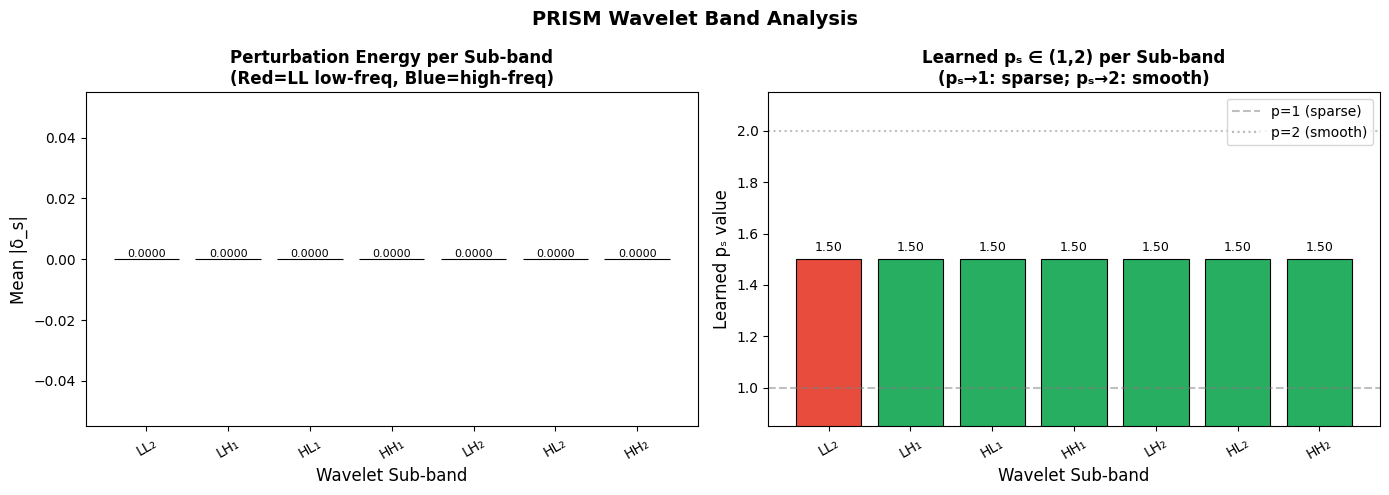

In [17]:
# Run a short optimisation on a small sample to extract wavelet stats
_vis_imgs = samp_orig_lfw[:4].to(device)
B_vis, C_vis, H_vis, W_vis = _vis_imgs.shape

_pert_vis = WaveletPerturbation(
    batch_size=B_vis, img_size=H_vis, channels=C_vis,
    wavelet=cfg.wavelet, J=cfg.J, band_weights=cfg.band_w, epsilon=cfg.epsilon
).to(device)

_opt_vis = torch.optim.Adam(
    [_pert_vis.delta_ll] + list(_pert_vis.delta_high) + list(_pert_vis.log_p),
    lr=cfg.lr_delta
)

with torch.no_grad():
    _orig_embs_vis = [m(_vis_imgs).detach() for m in surrogate_models]
_G_vis = ensemble_fim_diagonal(surrogate_models, _vis_imgs, n_samples=cfg.n_fim)

print("Running wavelet-stats optimisation …")
for _it in tqdm(range(cfg.n_iter)):
    _opt_vis.zero_grad()
    _P = _pert_vis.get_perturbation()
    _anon = (_vis_imgs + _P).clamp(-1.0, 1.0)
    _l_priv, _ = riemannian_privacy_loss(
        surrogate_models, _orig_embs_vis, _anon, _G_vis, alpha=cfg.alpha
    )
    _l_util = _pert_vis.utility_loss()
    (_l_priv + cfg.lambda1 * _l_util).backward()
    _opt_vis.step()
    _pert_vis.clamp_budgets()

band_names  = ["LL₂", "LH₁", "HL₁", "HH₁", "LH₂", "HL₂", "HH₂"]
band_energy = [_pert_vis.delta_ll.detach().abs().mean().item()]
for j in range(cfg.J):
    for ori in range(3):
        band_energy.append(
            _pert_vis.delta_high[j][:, :, ori, :, :].detach().abs().mean().item()
        )
p_values = [pv.item() for pv in _pert_vis.get_p_values()]

del _pert_vis, _opt_vis, _orig_embs_vis, _G_vis; torch.cuda.empty_cache()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#e74c3c"] + ["#3498db"] * 6
bars   = axes[0].bar(band_names, band_energy, color=colors, edgecolor="black", linewidth=0.8)
axes[0].set_xlabel("Wavelet Sub-band", fontsize=12)
axes[0].set_ylabel("Mean |δ_s|", fontsize=12)
axes[0].set_title("Perturbation Energy per Sub-band\n(Red=LL low-freq, Blue=high-freq)",
                  fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)
for bar, v in zip(bars, band_energy):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2e-5,
                 f"{v:.4f}", ha="center", va="bottom", fontsize=8)

p_colors = ["#e74c3c"] + ["#27ae60"] * 6
axes[1].bar(band_names, p_values, color=p_colors, edgecolor="black", linewidth=0.8)
axes[1].set_xlabel("Wavelet Sub-band", fontsize=12)
axes[1].set_ylabel("Learned pₛ value", fontsize=12)
axes[1].set_title("Learned pₛ ∈ (1,2) per Sub-band\n(pₛ→1: sparse; pₛ→2: smooth)",
                  fontweight="bold")
axes[1].axhline(1.0, color="gray", ls="--", alpha=0.5, label="p=1 (sparse)")
axes[1].axhline(2.0, color="gray", ls=":",  alpha=0.5, label="p=2 (smooth)")
axes[1].set_ylim(0.85, 2.15)
axes[1].legend(); axes[1].tick_params(axis="x", rotation=30)
for idx, (name, pv) in enumerate(zip(band_names, p_values)):
    axes[1].text(idx, pv + 0.02, f"{pv:.2f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("PRISM Wavelet Band Analysis", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


## 🔵 Embedding Space Analysis

Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
Computing ensemble FI

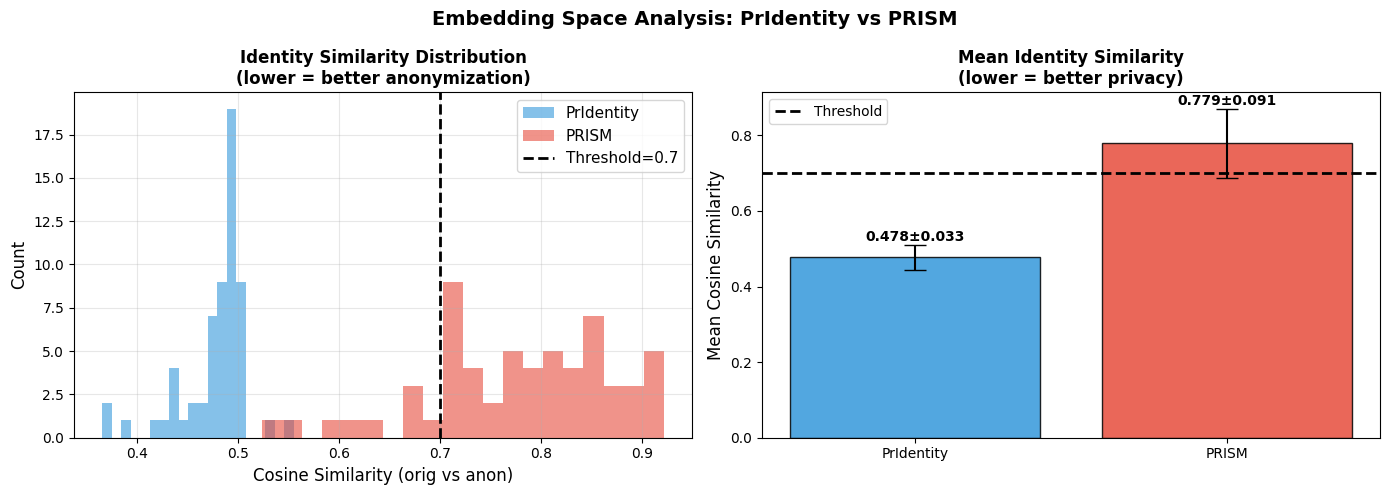

PrIdentity  cos-sim: 0.4777 ± 0.0331
PRISM       cos-sim: 0.7792 ± 0.0914
PRISM advantage    : -0.3015 lower similarity


In [18]:
n_compare       = min(64, cfg.n_eval)
all_cos_prid    = []
all_cos_prism   = []

for i, (batch, _, _) in enumerate(lfw_loader):
    if i * cfg.batch_size >= n_compare:
        break
    batch = batch.to(device)
    prid  = pridentity_fn(batch)
    prism = prism_fn(batch)
    with torch.no_grad():
        z_o = F.normalize(surrogate_models[0](batch), dim=-1)
        z_p = F.normalize(surrogate_models[0](prid),  dim=-1)
        z_q = F.normalize(surrogate_models[0](prism), dim=-1)
    all_cos_prid.extend( (z_o * z_p).sum(-1).cpu().tolist() )
    all_cos_prism.extend((z_o * z_q).sum(-1).cpu().tolist() )
    del batch, prid, prism, z_o, z_p, z_q; torch.cuda.empty_cache()

all_cos_prid  = np.array(all_cos_prid[:n_compare])
all_cos_prism = np.array(all_cos_prism[:n_compare])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_cos_prid,  bins=20, alpha=0.6, color="#3498db", ec="black", label="PrIdentity")
axes[0].hist(all_cos_prism, bins=20, alpha=0.6, color="#e74c3c", ec="black", label="PRISM")
axes[0].axvline(cfg.verif_threshold, color="k", ls="--", lw=2, label=f"Threshold={cfg.verif_threshold}")
axes[0].set_xlabel("Cosine Similarity (orig vs anon)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Identity Similarity Distribution\n(lower = better anonymization)",
                  fontweight="bold")
axes[0].legend(fontsize=11); axes[0].grid(alpha=0.3)

methods = ["PrIdentity", "PRISM"]
means   = [all_cos_prid.mean(),  all_cos_prism.mean()]
stds    = [all_cos_prid.std(),   all_cos_prism.std()]
bars    = axes[1].bar(methods, means, yerr=stds, capsize=8,
                      color=["#3498db","#e74c3c"], ec="black", alpha=0.85)
axes[1].axhline(cfg.verif_threshold, color="k", ls="--", lw=2, label="Threshold")
axes[1].set_ylabel("Mean Cosine Similarity", fontsize=12)
axes[1].set_title("Mean Identity Similarity\n(lower = better privacy)", fontweight="bold")
axes[1].legend()
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x() + bar.get_width()/2, m + s + 0.01,
                 f"{m:.3f}±{s:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Embedding Space Analysis: PrIdentity vs PRISM", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"PrIdentity  cos-sim: {all_cos_prid.mean():.4f} ± {all_cos_prid.std():.4f}")
print(f"PRISM       cos-sim: {all_cos_prism.mean():.4f} ± {all_cos_prism.std():.4f}")
print(f"PRISM advantage    : {all_cos_prid.mean() - all_cos_prism.mean():.4f} lower similarity")


## ⚖️ Privacy–Utility Trade-off Curve

Sweeping ε for privacy–utility trade-off curve …
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
  ε=0.02 | PrId: SSIM=0.967, TPR=0.750 | PRISM: SSIM=0.983, TPR=1.000
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
  ε=0.04 | PrId: SSIM=0.935, TPR=0.625 | PRISM: SSIM=0.948, TPR=1.000
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
  ε=0.06 | PrId: SSIM=0.895, TPR=0.000 | PRISM: SSIM=0.917, TPR=0.625
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
  ε=0.08 | PrId: SSIM=0.874, TPR=0.000 | PRISM: SSIM=0.897, TPR=0.625
Computing ensemble FIM (n_samples=8) …
Computing Jacobian subspace (k=6, power_iter=2) …
  ε=0.10 | PrId: SSIM=0.863, TPR=0.000 | PRISM: SSIM=0.884, TPR=0.125


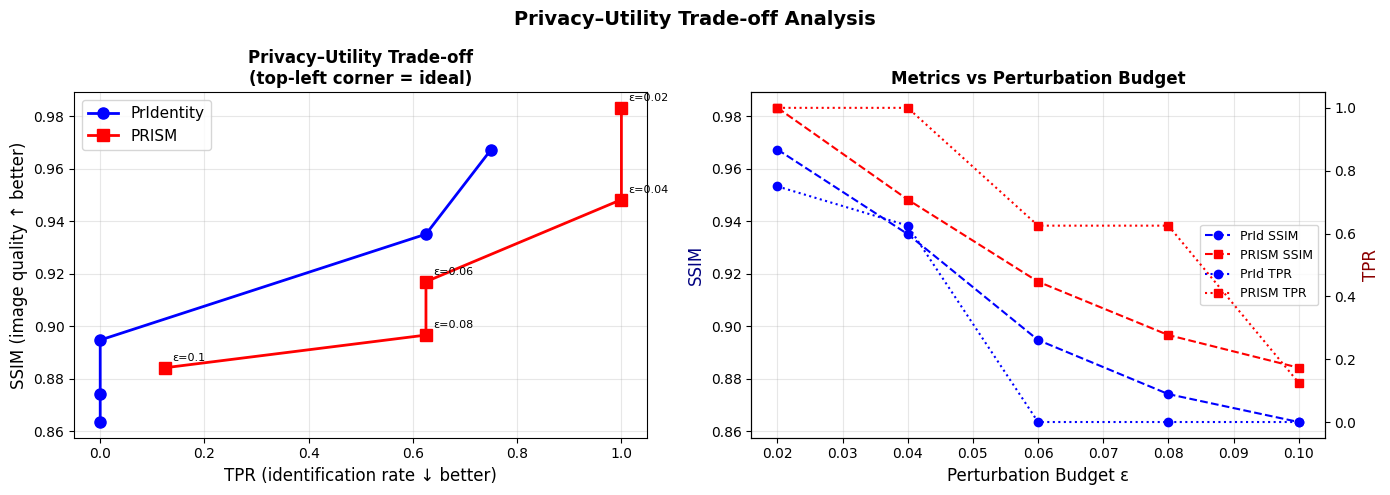

In [19]:
epsilons    = [0.02, 0.04, 0.06, 0.08, 0.10]
curve_prid  = {"ssim": [], "tpr": []}
curve_prism = {"ssim": [], "tpr": []}

_sweep_imgs = samp_orig_lfw[:16].to(device)

print("Sweeping ε for privacy–utility trade-off curve …")
for eps in epsilons:
    # Temporary config with modified epsilon
    _cfg        = Config()
    _cfg.epsilon = eps
    _cfg.n_iter  = 80   # fewer iters for speed in sweep

    # PrIdentity
    _prid = run_pridentity(_sweep_imgs, surrogate_models, _cfg)
    _s_p, _ = compute_ssim_batch(_sweep_imgs.cpu(), _prid.cpu())
    _t_p, _ = compute_privacy_whitebox(surrogate_models[0], _sweep_imgs, _prid,
                                        threshold=cfg.verif_threshold)
    curve_prid["ssim"].append(_s_p);  curve_prid["tpr"].append(_t_p)

    # PRISM
    _prism, _, _, _ = run_prism(_sweep_imgs, surrogate_models, _cfg)
    _s_q, _ = compute_ssim_batch(_sweep_imgs.cpu(), _prism.cpu())
    _t_q, _ = compute_privacy_whitebox(surrogate_models[0], _sweep_imgs, _prism,
                                        threshold=cfg.verif_threshold)
    curve_prism["ssim"].append(_s_q); curve_prism["tpr"].append(_t_q)

    del _prid, _prism; torch.cuda.empty_cache()
    print(f"  ε={eps:.2f} | PrId: SSIM={_s_p:.3f}, TPR={_t_p:.3f} | "
          f"PRISM: SSIM={_s_q:.3f}, TPR={_t_q:.3f}")

del _sweep_imgs; torch.cuda.empty_cache()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(curve_prid["tpr"],  curve_prid["ssim"],  "b-o", ms=8, lw=2, label="PrIdentity")
axes[0].plot(curve_prism["tpr"], curve_prism["ssim"], "r-s", ms=8, lw=2, label="PRISM")
for i, eps in enumerate(epsilons):
    axes[0].annotate(f"ε={eps}", (curve_prism["tpr"][i], curve_prism["ssim"][i]),
                     textcoords="offset points", xytext=(5,5), fontsize=8)
axes[0].set_xlabel("TPR (identification rate ↓ better)", fontsize=12)
axes[0].set_ylabel("SSIM (image quality ↑ better)", fontsize=12)
axes[0].set_title("Privacy–Utility Trade-off\n(top-left corner = ideal)", fontweight="bold")
axes[0].legend(fontsize=11); axes[0].grid(alpha=0.3)

ax2 = axes[1].twinx()
l1, = axes[1].plot(epsilons, curve_prid["ssim"],  "b--o", ms=6, label="PrId SSIM")
l2, = axes[1].plot(epsilons, curve_prism["ssim"], "r--s", ms=6, label="PRISM SSIM")
l3, = ax2.plot(epsilons,     curve_prid["tpr"],   "b:o",  ms=6, label="PrId TPR")
l4, = ax2.plot(epsilons,     curve_prism["tpr"],  "r:s",  ms=6, label="PRISM TPR")
axes[1].set_xlabel("Perturbation Budget ε", fontsize=12)
axes[1].set_ylabel("SSIM", fontsize=12, color="navy")
ax2.set_ylabel("TPR", fontsize=12, color="darkred")
axes[1].set_title("Metrics vs Perturbation Budget", fontweight="bold")
axes[1].legend(handles=[l1,l2,l3,l4], loc="center right", fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle("Privacy–Utility Trade-off Analysis", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


## 📊 Final Results Table

In [20]:
def fmt_delta(prism_val, prid_val, higher_better: bool = True) -> str:
    delta = prism_val - prid_val
    if higher_better:
        arrow, ok = ("▲", "✅") if delta > 0 else ("▼", "⚠️")
    else:
        arrow, ok = ("▼", "✅") if delta < 0 else ("▲", "⚠️")
    return f"{arrow}{abs(delta):.4f} {ok}"

def build_table(res_prid, res_prism):
    return [
        ["SSIM ↑",          f"{res_prid['SSIM']:.4f}",     f"{res_prism['SSIM']:.4f}",    fmt_delta(res_prism['SSIM'],    res_prid['SSIM'],    True)],
        ["PSNR ↑ (dB)",     f"{res_prid['PSNR']:.2f}",     f"{res_prism['PSNR']:.2f}",    fmt_delta(res_prism['PSNR'],    res_prid['PSNR'],    True)],
        ["TPR White-box ↓", f"{res_prid['TPR_WB']:.4f}",   f"{res_prism['TPR_WB']:.4f}",  fmt_delta(res_prism['TPR_WB'],  res_prid['TPR_WB'],  False)],
        ["TPR Black-box ↓", f"{res_prid['TPR_BB']:.4f}",   f"{res_prism['TPR_BB']:.4f}",  fmt_delta(res_prism['TPR_BB'],  res_prid['TPR_BB'],  False)],
        ["CosSim WB ↓",     f"{res_prid['CosSimWB']:.4f}", f"{res_prism['CosSimWB']:.4f}",fmt_delta(res_prism['CosSimWB'],res_prid['CosSimWB'],False)],
        ["CosSim BB ↓",     f"{res_prid['CosSimBB']:.4f}", f"{res_prism['CosSimBB']:.4f}",fmt_delta(res_prism['CosSimBB'],res_prid['CosSimBB'],False)],
        ["BB Distance ↓",   f"{res_prid['BBDist']:.4f}",   f"{res_prism['BBDist']:.4f}",  fmt_delta(res_prism['BBDist'],  res_prid['BBDist'],  False)],
        ["Trade-off T ↑",   f"{res_prid['T_score']:.4f}",  f"{res_prism['T_score']:.4f}", fmt_delta(res_prism['T_score'], res_prid['T_score'], True)],
    ]

headers = ["Metric", "PrIdentity", "PRISM", "PRISM − PrIdentity"]

print("\n" + "="*65)
print("  DATASET: LFW — Labelled Faces in the Wild")
print("="*65)
print(tabulate(build_table(res_prid_lfw, res_prism_lfw), headers=headers, tablefmt="grid"))

print("\n" + "="*65)
print("  DATASET: CelebA-HQ")
print("="*65)
print(tabulate(build_table(res_prid_celeba, res_prism_celeba), headers=headers, tablefmt="grid"))



  DATASET: LFW — Labelled Faces in the Wild
+-----------------+--------------+---------+----------------------+
| Metric          |   PrIdentity |   PRISM | PRISM − PrIdentity   |
+=================+==============+=========+======================+
| SSIM ↑          |       0.9194 |  0.9327 | ▲0.0133 ✅           |
+-----------------+--------------+---------+----------------------+
| PSNR ↑ (dB)     |      35.84   | 37.36   | ▲1.5212 ✅           |
+-----------------+--------------+---------+----------------------+
| TPR White-box ↓ |       0      |  0.7833 | ▲0.7833 ⚠️           |
+-----------------+--------------+---------+----------------------+
| TPR Black-box ↓ |       0      |  0.0167 | ▲0.0167 ⚠️           |
+-----------------+--------------+---------+----------------------+
| CosSim WB ↓     |       0.4753 |  0.7688 | ▲0.2935 ⚠️           |
+-----------------+--------------+---------+----------------------+
| CosSim BB ↓     |       0.4399 |  0.4218 | ▼0.0181 ✅           |
+-----

## 🎯 Radar Chart & Bar Comparison

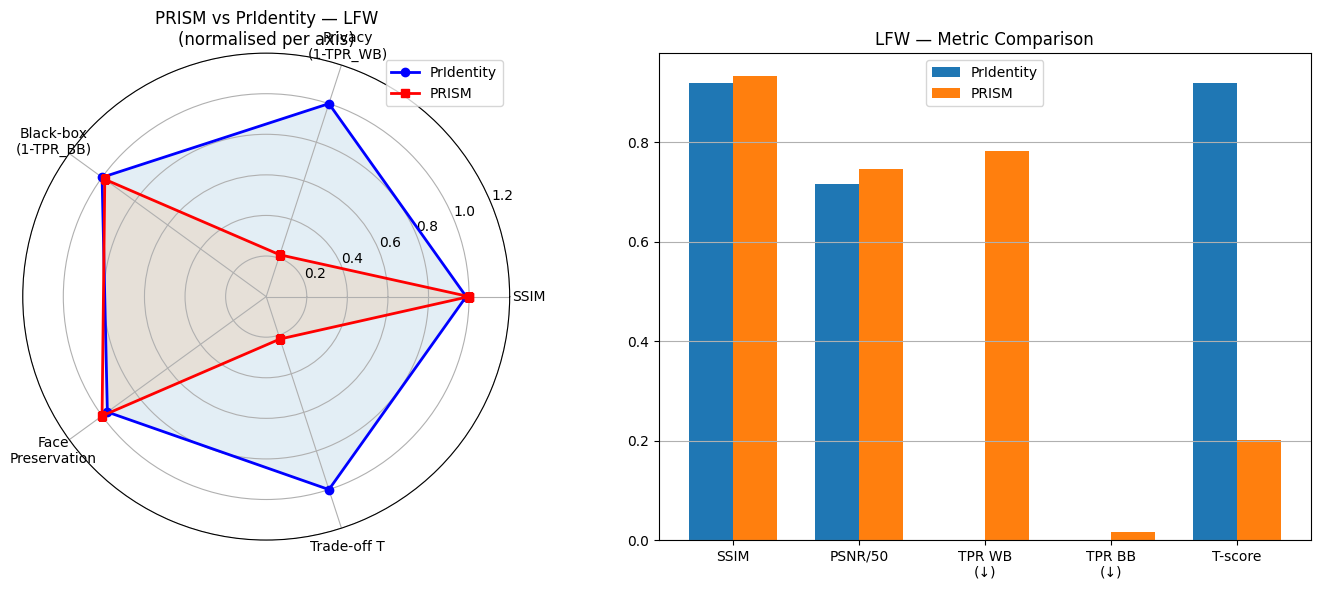

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------ Build bar data AGAIN (important) ------------------
prid_bar = [
    res_prid_lfw["SSIM"],
    res_prid_lfw["PSNR"] / 50,
    res_prid_lfw["TPR_WB"],
    res_prid_lfw["TPR_BB"],
    res_prid_lfw["T_score"]
]

prism_bar = [
    res_prism_lfw["SSIM"],
    res_prism_lfw["PSNR"] / 50,
    res_prism_lfw["TPR_WB"],
    res_prism_lfw["TPR_BB"],
    res_prism_lfw["T_score"]
]

# ------------------ Radar ------------------
def radar_values(res):
    return [
        res["SSIM"],
        1 - res["TPR_WB"],
        1 - res["TPR_BB"],
        max(0.0, 1 - res["BBDist"]),
        res["T_score"],
    ]

labels = [
    "SSIM",
    "Privacy\n(1-TPR_WB)",
    "Black-box\n(1-TPR_BB)",
    "Face\nPreservation",
    "Trade-off T"
]

n_cats = len(labels)
angles = [n / float(n_cats) * 2 * np.pi for n in range(n_cats)]
angles += angles[:1]

def normalise_radar(prid_v, prism_v):
    maxv = [max(a, b) + 1e-8 for a, b in zip(prid_v, prism_v)]
    return (
        [v / m for v, m in zip(prid_v, maxv)] + [prid_v[0] / maxv[0]],
        [v / m for v, m in zip(prism_v, maxv)] + [prism_v[0] / maxv[0]],
    )

prid_n, prism_n = normalise_radar(
    radar_values(res_prid_lfw),
    radar_values(res_prism_lfw)
)

# ------------------ Plot ------------------
fig = plt.figure(figsize=(14, 6))

# Radar
ax_r = fig.add_subplot(121, polar=True)
ax_r.plot(angles, prid_n, "b-o", lw=2, label="PrIdentity")
ax_r.fill(angles, prid_n, alpha=0.12)

ax_r.plot(angles, prism_n, "r-s", lw=2, label="PRISM")
ax_r.fill(angles, prism_n, alpha=0.12)

ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(labels)
ax_r.set_ylim(0, 1.2)
ax_r.set_title("PRISM vs PrIdentity — LFW\n(normalised per axis)")
ax_r.legend()
ax_r.grid(True)

# Bar chart
ax_b = fig.add_subplot(122)

metric_labels = [
    "SSIM",
    "PSNR/50",
    "TPR WB\n(↓)",
    "TPR BB\n(↓)",
    "T-score"
]

x = np.arange(len(metric_labels))
w = 0.35

b1 = ax_b.bar(x - w/2, prid_bar, w, label="PrIdentity")
b2 = ax_b.bar(x + w/2, prism_bar, w, label="PRISM")

ax_b.set_xticks(x)
ax_b.set_xticklabels(metric_labels)
ax_b.set_title("LFW — Metric Comparison")
ax_b.legend()
ax_b.grid(axis="y")

plt.tight_layout()
plt.show()

## 💾 Save Results

In [24]:
all_results = {
    "lfw": {
        "PrIdentity": res_prid_lfw,
        "PRISM":      res_prism_lfw,
    },
    "celeba_hq": {
        "PrIdentity": res_prid_celeba,
        "PRISM":      res_prism_celeba,
    },
    "config": {
        "epsilon":   cfg.epsilon,
        "n_iter":    cfg.n_iter,
        "alpha":     cfg.alpha,
        "lambda1":   cfg.lambda1,
        "lambda2":   cfg.lambda2,
        "k_sub":     cfg.k_sub,
        "wavelet":   cfg.wavelet,
        "J":         cfg.J,
        "n_eval":    cfg.n_eval,
    },
}

res_path = os.path.join(cfg.out_dir, "prism_results.json")
with open(res_path, "w") as f:
    json.dump(all_results, f, indent=2)
print(f"✅ Results saved to {res_path}")

print("\n" + "="*65)
print("  FINAL RESULTS SUMMARY")
print("="*65)
for ds_name, ds_res in all_results.items():
    if ds_name == "config":
        continue
    print(f"\nDataset: {ds_name.upper()}")
    for method, metrics in ds_res.items():
        print(f"  [{method}]")
        for k, v in metrics.items():
            print(f"    {k:<20}: {v:.4f}")

print("\n✅ PRISM notebook complete — all results saved.")


✅ Results saved to /kaggle/working/prism_results/prism_results.json

  FINAL RESULTS SUMMARY

Dataset: LFW
  [PrIdentity]
    SSIM                : 0.9194
    PSNR                : 35.8368
    TPR_WB              : 0.0000
    TPR_BB              : 0.0000
    CosSimWB            : 0.4753
    CosSimBB            : 0.4399
    BBDist              : 0.0778
    T_score             : 0.9194
  [PRISM]
    SSIM                : 0.9327
    PSNR                : 37.3579
    TPR_WB              : 0.7833
    TPR_BB              : 0.0167
    CosSimWB            : 0.7688
    CosSimBB            : 0.4218
    BBDist              : 0.0469
    T_score             : 0.2021

Dataset: CELEBA_HQ
  [PrIdentity]
    SSIM                : 0.9325
    PSNR                : 35.6392
    TPR_WB              : 0.0000
    TPR_BB              : 0.0000
    CosSimWB            : 0.4794
    CosSimBB            : 0.4628
    BBDist              : 0.0301
    T_score             : 0.9325
  [PRISM]
    SSIM                : 0.